### Description:
This model fuses Swin Transformer image tokens with a single tabular token via cross-attention, where the tabular token acts as the query (Q) and the image tokens act as keys (K) and values (V). The cross-attention output is normalized and passed through an MLP head to produce the final scalar prediction. Despite integrating tabular information, the main data flow still relies on the rich spatial features from the image backbone.

### Analysis:
Cross-attention did not improve performance over the single Swin Transformer (RMSE 17.71 vs 17.71) and was slightly worse than early concatenation without attention and interaction of the tabular and image data where RMSE was (17.60). This indicates that cross-attention may not effectively leverage weak tabular features, and the model’s predictions are still dominated by the image modality

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [ ]:
# imports and config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image

main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp5_swin_mid_cross_attention_fusion_v2")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp_cross_attn"]
cfg["name"] = "exp5_swin_mid_cross_attention_fusion_v2"
cfg["mode"] = "cross_attn_fusion"
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]
os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [5]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="cross_attn_fusion",      #  fusion
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      #  fold for each sample
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp5_swin_mid_cross_attention_fusion_v2: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[BCE]: Loss=0.6527 | ValRMSE: 18.0807
Epoch 2/10 | Fold 1 | Train[BCE]: Loss=0.6407 | ValRMSE: 17.6414
Epoch 3/10 | Fold 1 | Train[BCE]: Loss=0.6347 | ValRMSE: 17.7058
Epoch 4/10 | Fold 1 | Train[BCE]: Loss=0.6254 | ValRMSE: 18.2842
Epoch 5/10 | Fold 1 | Train[BCE]: Loss=0.6167 | ValRMSE: 17.9949
Epoch 6/10 | Fold 1 | Train[BCE]: Loss=0.6077 | ValRMSE: 18.1060
Epoch 7/10 | Fold 1 | Train[BCE]: Loss=0.6014 | ValRMSE: 18.4039
Early stopping at epoch 7
Fold 1 best RMSE: 17.6414

=== exp5_swin_mid_cross_attention_fusion_v2: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[BCE]: Loss=0.6501 | ValRMSE: 18.3031
Epoch 2/10 | Fold 2 | Train[BCE]: Loss=0.6399 | ValRMSE: 17.9251
Epoch 3/10 | Fold 2 | Train[BCE]: Loss=0.6321 | ValRMSE: 18.2760
Epoch 4/10 | Fold 2 | Train[BCE]: Loss=0.6238 | ValRMSE: 18.1504
Epoch 5/10 | Fold 2 | Train[BCE]: Loss=0.6141 | ValRMSE: 18.4427
Epoch 6/10 | Fold 2 | Train[BCE]: Loss=0.6046 | ValRMS

In [14]:
import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.6414 (n=1983)
Fold 2 OOF RMSE: 17.9251 (n=1983)
Fold 3 OOF RMSE: 17.4250 (n=1982)
Fold 4 OOF RMSE: 17.6249 (n=1982)
Fold 5 OOF RMSE: 17.9543 (n=1982)


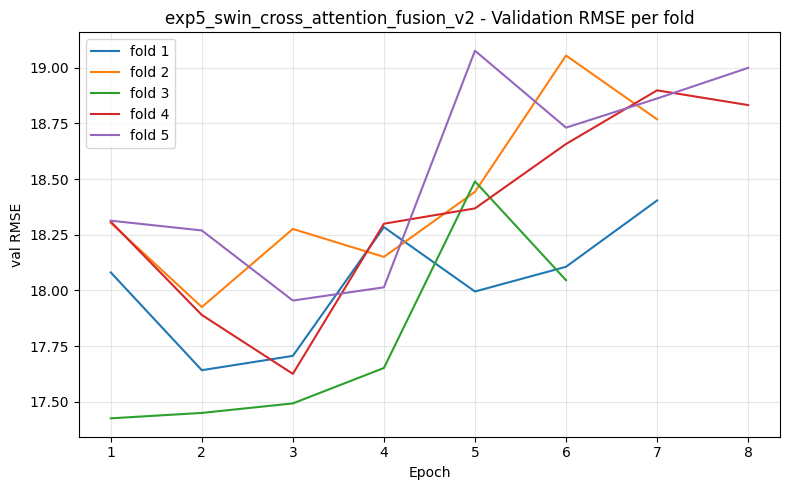

In [15]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="exp5_swin_cross_attention_fusion_v2")

In [16]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()


,Id,fold,ytrue,oof_pred,abs_err
0,4c1e05895368c997fdd709bbd1ac3dae,2,2,79.109322,77.109322
1,f4dd9ea389798d703ee5ebe2a82c8653,5,2,77.982338,75.982338
2,d00e5d29d4ec09de1e0e0ebec41b2d03,1,5,77.933769,72.933769
3,3d946559e2b4b210a06e9103b0dd72e9,2,5,77.716431,72.716431
4,380cdda7ceba006f13675d19d0b38b1c,2,100,27.586195,72.413805


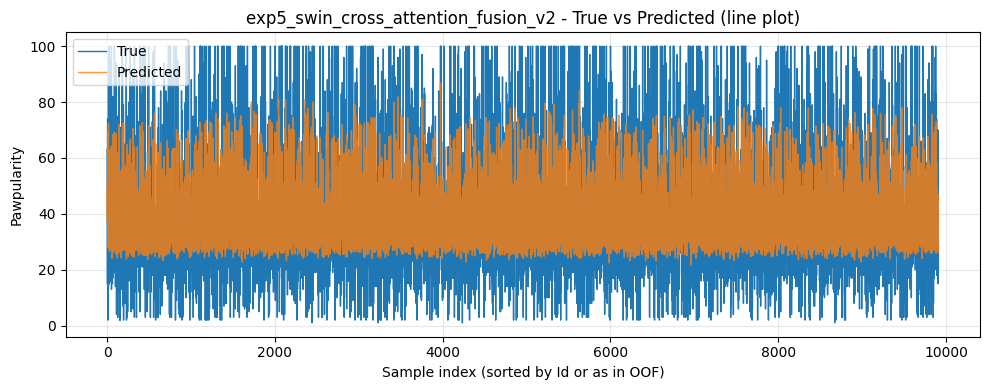

In [17]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="exp5_swin_cross_attention_fusion_v2")



